In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torchvision import datasets as datasetsvision
from torchvision import transforms
from PIL import Image, ImageFilter
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.decomposition import PCA
import pandas as pd
import random

In [2]:
def make_mlp(input_dim: int, hidden_dim: int, output_dim: int, n_layers: int = 2):
    layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]
    for _ in range(n_layers - 1):
        layers += [nn.Linear(hidden_dim, hidden_dim), nn.ReLU()]
    layers.append(nn.Linear(hidden_dim, output_dim))
    return nn.Sequential(*layers)


In [3]:
class CouplingBlock(nn.Module):
    def __init__(self, input_size, hidden_size, condition_size = None, n_layers = 2):
        super(CouplingBlock, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.condition_size = condition_size

        half = input_size // 2

        if condition_size is None:
            self.nested_scale = make_mlp(half, hidden_size, half, n_layers)
            self.nested_translate = make_mlp(half, hidden_size, half, n_layers)
        else:
            in_dim = condition_size + half
            self.nested_scale = make_mlp(in_dim, hidden_size, half, n_layers)
            self.nested_translate = make_mlp(in_dim, hidden_size, half, n_layers)

    def forward(self, x, condition=None):
        x1, x2 = x[:, :self.input_size // 2], x[:, self.input_size // 2:]
        if condition is None:
            z1 = x1
            scale = torch.exp(torch.tanh(self.nested_scale(x1)))
            z2 = x2 * scale + self.nested_translate(x1)
        else:
            x1_conditioned = torch.cat([x1, condition], dim=1)
            scale = torch.exp(torch.tanh(self.nested_scale(x1_conditioned)))
            z1 = x1
            z2 = x2 * scale + self.nested_translate(x1_conditioned)

        return torch.cat([z1,z2], dim=1), scale
    
    def reverse(self, Z, condition=None):
        z1, z2 = Z[:, :self.input_size // 2], Z[:, self.input_size // 2:]
        if condition is None:
            scale =  torch.exp(torch.tanh(self.nested_scale(z1)))
            x1 = z1
            x2 = (z2 - self.nested_translate(z1)) / scale
        else:
            z1_conditioned = torch.cat([z1, condition],dim=1)
            scale = torch.exp(torch.tanh(self.nested_scale(z1_conditioned)))
            x1 = z1
            x2 = (z2 - self.nested_translate(z1_conditioned)) / scale
        return torch.cat([x1,x2], dim=1)

In [4]:
class RealNVP(nn.Module):
    def __init__(self, input_size, hidden_size, blocks, condition_size = None):
        super(RealNVP, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.condition_size = condition_size
        if condition_size is None:
            self.coupling_blocks = nn.ModuleList([
                CouplingBlock(input_size, hidden_size) for _ in range(blocks)
            ])
        else:
            self.coupling_blocks = nn.ModuleList([
                CouplingBlock(input_size, hidden_size, condition_size) for _ in range(blocks)
            ])
        self.rotations = [torch.linalg.qr(torch.randn(input_size, input_size))[0] for _ in range(blocks - 1)]
        self.rotations = nn.ParameterList([nn.Parameter(rot, requires_grad=False) for rot in self.rotations])
        
    def forward(self, x, condition=None):
        log_det_jacob = 0
        for i, block in enumerate(self.coupling_blocks):
            if condition is None:
                x, scale = block(x)
            else:
                x, scale = block(x, condition)
            log_det_jacob += torch.sum(torch.log(scale), dim=1)
            if i < len(self.rotations):
                x = x @ self.rotations[i]
        return x, log_det_jacob
    
    def reverse(self, z, condition=None):
        for i in reversed(range(len(self.coupling_blocks))):
            if i < len(self.rotations):
                z = z @ self.rotations[i].T
            if condition is None:
                z = self.coupling_blocks[i].reverse(z)
            else:
                z = self.coupling_blocks[i].reverse(z, condition)
        return z
    
    def sample(self, n_samples, conditions=None, n_labels=2):
        if conditions is None:
            gauss = torch.randn(n_samples, self.input_size)
            samples = self.reverse(gauss)
        else:
            conditions = torch.nn.functional.one_hot(torch.tensor(conditions, dtype=torch.int64), num_classes=n_labels).float()
            conditions_repeated = conditions.repeat(n_samples, 1)
            gauss = torch.randn(n_samples * len(conditions), self.input_size)
            samples = self.reverse(gauss, conditions_repeated)

        return samples


In [5]:
def get_moons_unconditional(n_samples=1000, noise=0.1):
    X, _ = datasets.make_moons(n_samples=n_samples, noise=noise)
    X = torch.tensor(X, dtype=torch.float32)
    dataset = torch.utils.data.TensorDataset(X)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)
    return dataloader, X

def get_moons_conditional(n_samples=1000, noise=0.1):
    X, y = datasets.make_moons(n_samples=n_samples, noise=noise)
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.nn.functional.one_hot(
        torch.tensor(y), num_classes=2
    ).float()
    dataset = torch.utils.data.TensorDataset(X, y)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)
    return dataloader, X, y

In [6]:
def train_inn(model, dataloader, n_samples=1000, epochs=100, lr = 0.001):
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    loss_values = []

    for _ in range(epochs):
        total_training_loss = 0
        for batch in dataloader:
            x=batch[0]
            if model.condition_size is not None:
                y = batch[1]
                z, log_det_jacob = model(x, y)
            else:
                z, log_det_jacob = model(x)
            loss = torch.mean(1/2 * x.shape[1] * torch.log(torch.tensor(2*torch.pi)) + 1/2 * torch.sum(z ** 2, dim=1) - log_det_jacob)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_training_loss += loss.item()
        loss_values.append(total_training_loss)

    return model, loss_values    

In [8]:
def plot_lc(losses):
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.show()

In [9]:

uncond_loader, X_uncond = get_moons_unconditional(n_samples=5000)
cond_loader, X_cond, y_cond = get_moons_conditional(n_samples=5000)

input_size = X_uncond.shape[1]
hidden_size = 64
n_blocks = 5
condition_size = 2 

rnvp = RealNVP(input_size, hidden_size, n_blocks)
cond_rnvp = RealNVP(input_size, hidden_size, n_blocks, condition_size)

rnvp, losses = train_inn(rnvp, uncond_loader)
cond_rnvp, cond_losses = train_inn(cond_rnvp, cond_loader)

gen_X = rnvp.sample(2000)


gen_moon_0 = cond_rnvp.sample(2000, [0])
gen_moon_1 = cond_rnvp.sample(2000, [1])

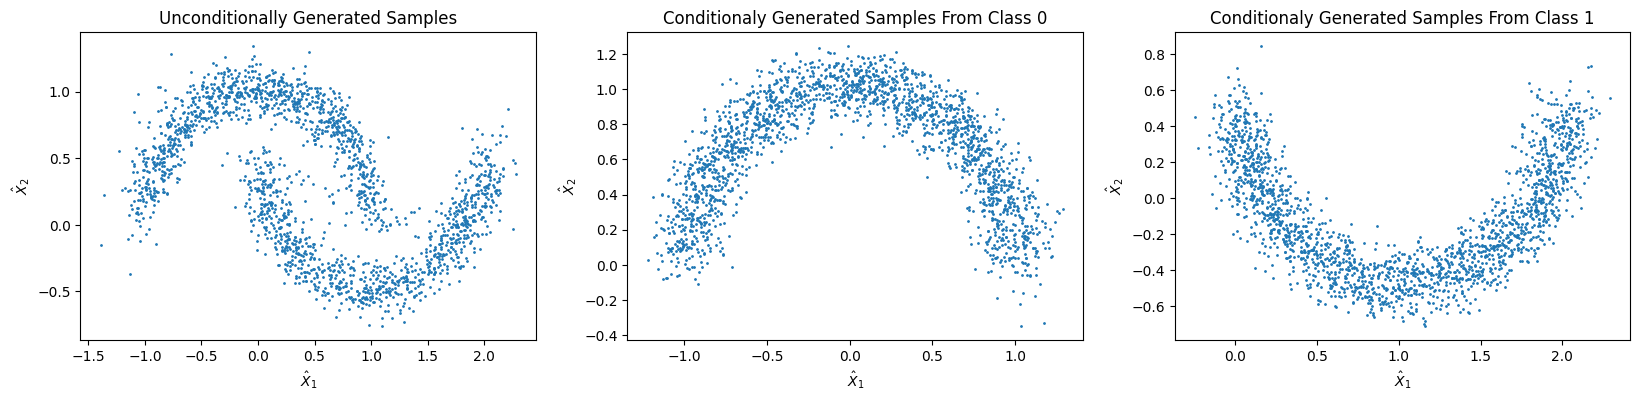

In [15]:
fig, axs = plt.subplots(1,3, figsize=(20,4))
axs[0].set_title("Unconditionally Generated Samples")
axs[0].scatter(gen_X.detach().numpy()[:,0], gen_X.detach().numpy()[:,1], s=1, label="Generated Data")
axs[0].set_xlabel(r"$\hat{X}_1$")
axs[0].set_ylabel(r"$\hat{X}_2$")

axs[1].set_title("Conditionaly Generated Samples From Class 0")
axs[1].scatter(gen_moon_0[:,0].detach().numpy(), gen_moon_0[:,1].detach().numpy(), s=1)
axs[1].set_xlabel(r"$\hat{X}_1$")
axs[1].set_ylabel(r"$\hat{X}_2$")

axs[2].set_title("Conditionaly Generated Samples From Class 1")
axs[2].scatter(gen_moon_1[:,0].detach().numpy(), gen_moon_1[:,1].detach().numpy(), s=1)
axs[2].set_xlabel(r"$ \hat{X}_1$")
axs[2].set_ylabel(r"$ \hat{X}_2$")

plt.show()

In [11]:
import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

def count_params(model):
    return sum(p.numel() for p in model.parameters())

@torch.no_grad()
def eval_nll(model, dataloader, device=None):
    model.eval()
    if device is None:
        device = next(model.parameters()).device

    total_nll = 0.0
    total_n = 0

    for batch in dataloader:
        x = batch[0].to(device)
        D = x.shape[1]
        const = 0.5 * D * torch.log(torch.tensor(2 * torch.pi, device=device))

        if getattr(model, "condition_size", None) is not None:
            y = batch[1].to(device)
            z, log_det = model(x, y)
        else:
            z, log_det = model(x)

        nll = const + 0.5 * torch.sum(z**2, dim=1) - log_det
        total_nll += nll.sum().item()
        total_n += x.size(0)

    return total_nll / total_n

def _rbf_kernel(x, y, sigma):
    x_norm = (x**2).sum(dim=1, keepdim=True)
    y_norm = (y**2).sum(dim=1, keepdim=True).t()
    dist2 = x_norm + y_norm - 2.0 * x @ y.t()
    return torch.exp(-dist2 / (2.0 * sigma**2))

@torch.no_grad()
def mmd_rbf(x, y, sigma=None, max_pts=1000):
    x = x.detach()
    y = y.detach()

    if sigma is None:
        z = torch.cat([x, y], dim=0)
        if z.size(0) > max_pts:
            idx = torch.randperm(z.size(0))[:max_pts]
            z = z[idx]
        z_norm = (z**2).sum(dim=1, keepdim=True)
        dist2 = z_norm + z_norm.t() - 2.0 * z @ z.t()
        dist2 = dist2[torch.triu(torch.ones_like(dist2), diagonal=1) == 1]
        median_dist = torch.sqrt(torch.median(dist2).clamp(min=1e-12))
        sigma = median_dist.item()

    Kxx = _rbf_kernel(x, x, sigma)
    Kyy = _rbf_kernel(y, y, sigma)
    Kxy = _rbf_kernel(x, y, sigma)

    n = x.size(0)
    m = y.size(0)
    if n > 1:
        Kxx = Kxx - torch.diag(torch.diag(Kxx))
        mmd_xx = Kxx.sum() / (n * (n - 1))
    else:
        mmd_xx = 0.0

    if m > 1:
        Kyy = Kyy - torch.diag(torch.diag(Kyy))
        mmd_yy = Kyy.sum() / (m * (m - 1))
    else:
        mmd_yy = 0.0

    mmd_xy = Kxy.mean()
    return float((mmd_xx + mmd_yy - 2.0 * mmd_xy).item())

@torch.no_grad()
def sampling_speed(model, sample_fn, n_samples=2000, n_repeats=20, warmup=5):
    model.eval()
    for _ in range(warmup):
        _ = sample_fn(n_samples)

    t0 = time.perf_counter()
    for _ in range(n_repeats):
        _ = sample_fn(n_samples)
    t1 = time.perf_counter()

    total = n_samples * n_repeats
    return total / (t1 - t0)


In [12]:
# --- fresh evaluation sets (recommended) ---
uncond_test_loader, X_test_uncond = get_moons_unconditional(n_samples=5000, noise=0.1)
cond_test_loader, X_test_cond, y_test_cond = get_moons_conditional(n_samples=5000, noise=0.1)

device = next(rnvp.parameters()).device

# --- sample adapters ---
def sample_rnvp_uncond(n):
    return rnvp.sample(n).to(device)

def sample_rnvp_cond_mix(n):
    n0 = n // 2
    n1 = n - n0
    s0 = cond_rnvp.sample(n0, [0]).to(device)
    s1 = cond_rnvp.sample(n1, [1]).to(device)
    return torch.cat([s0, s1], dim=0)

# --- compute metrics ---
rows = []

# Unconditional
nll = eval_nll(rnvp, uncond_test_loader, device=device)
gen = sample_rnvp_uncond(2000)
mmd = mmd_rbf(gen, X_test_uncond.to(device)[:2000])
sps = sampling_speed(rnvp, sample_rnvp_uncond, n_samples=2000)
rows.append({
    "Model": "RealNVP (uncond)",
    "Params": count_params(rnvp),
    "Test NLL ↓": nll,
    "MMD² ↓": mmd,
    "Sampling (samples/s) ↑": sps
})

# Conditional (mixture)
nll = eval_nll(cond_rnvp, cond_test_loader, device=device)
gen = sample_rnvp_cond_mix(2000)
mmd = mmd_rbf(gen, X_test_cond.to(device)[:2000])
sps = sampling_speed(cond_rnvp, sample_rnvp_cond_mix, n_samples=2000)
rows.append({
    "Model": "RealNVP (cond, mix)",
    "Params": count_params(cond_rnvp),
    "Test NLL ↓": nll,
    "MMD² ↓": mmd,
    "Sampling (samples/s) ↑": sps
})

rnvp_df = pd.DataFrame(rows)
rnvp_df


,Model,Params,Test NLL ↓,MMD² ↓,Sampling (samples/s) ↑
0,RealNVP (uncond),43546,1.085615,0.000153,826509.464556
1,"RealNVP (cond, mix)",44826,0.360222,-0.000105,404741.547262
